In [9]:
import pandas as pd
from sklearn.utils import resample
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


In [10]:
df = pd.read_csv("Iris.csv")

print(df.head())
print(df["Species"].value_counts().sort_index())


   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [11]:
# encode classes
le = LabelEncoder()
df["class"] = le.fit_transform(df["Species"].to_numpy())
print(df["class"].value_counts().sort_index())

class
0    50
1    50
2    50
Name: count, dtype: int64


In [12]:
# bootstraping
n_iterations = 1000
n_size = len(df)
features = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm", "class"]
stats = []

for i in range(n_iterations):
    train = resample(df[features].to_numpy(), replace=True, n_samples=n_size)
    
    model = DecisionTreeClassifier()
    model.fit(train[:, :-1], train[:, -1])
    
    oob = np.array([x for x in df[features].to_numpy() if x.tolist() not in train.tolist()])
    if len(oob) == 0:
        continue
    y_pred = model.predict(oob[:, :-1])
    score = accuracy_score(oob[:, -1], y_pred)
    stats.append(score)
    
stats = np.array(stats)

mean_score = np.mean(stats)
std_score = np.std(stats)
print(f'Mean OOB Accuracy: {mean_score:.3f}')
print(f'Standard Deviation: {std_score:.3f}')


Mean OOB Accuracy: 0.945
Standard Deviation: 0.029


95.0% Confidence Interval: [0.879, 1.000]


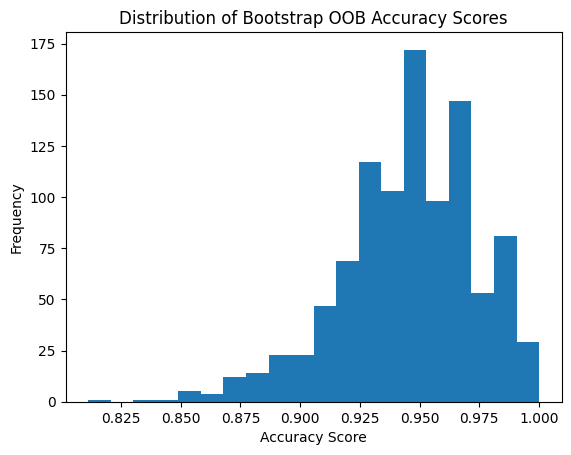

In [13]:
alpha = 0.95
p = ((1.0 - alpha) / 2.0) * 100
lower = np.percentile(stats, p)
p = (alpha + ((1.0 - alpha) / 2.0)) * 100
upper = np.percentile(stats, p)
print(f'{alpha*100:.1f}% Confidence Interval: [{lower:.3f}, {upper:.3f}]')

plt.hist(stats, bins=20)
plt.title('Distribution of Bootstrap OOB Accuracy Scores')
plt.xlabel('Accuracy Score')
plt.ylabel('Frequency')
plt.show()

In [18]:
# train model using slpit data
from sklearn.model_selection import train_test_split
X = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Test Set Accuracy: {acc:.3f}')


Test Set Accuracy: 1.000
